In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Figures 10.1-1 through 10.1-5 &mdash; hexane / triethylamine

**Five of the six hexane-triethylamine figures** that open Section 10.1: the total and
partial pressures and the $x$-$y$ diagram at 60 °C, the pressure-composition diagram at
the same temperature, and the temperature-composition and $x$-$y$ diagrams at a fixed
0.7 bar.

Hexane and triethylamine form an **essentially ideal** mixture, which is why the chapter
opens with them: Raoult's law applies, so the equilibrium pressure is linear in
composition and every diagram follows from two vapor pressures.

Figures 10.1-1 and 10.1-2 carry experimental points, and those points **are** the
argument: 10.1-1's three lines are exactly straight *by construction* under Raoult's law,
so without data it would assert ideality rather than demonstrate it. The measurements come
from the original paper &mdash; J. L. Humphrey and M. Van Winkle, *J. Chem. Eng. Data*
**12**, 526 (1967) &mdash; and not from the published figure art, which would be a worse source
than the table the art was drawn from.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.vle import GammaPhi, Ideal, TabulatedPsat, psat_from_database, pxy, txy
from thermo.vle_chart import pxy_chart, txy_chart, xy_chart, tie_lines, CELSIUS
from thermo.charts import use_book_style
use_book_style()

True

## Two vapor-pressure sources, on purpose

This notebook uses **two different sources for the same two vapor pressures**, and the
choice is deliberate, not laziness.

At 60 °C the chapter prints its own values &mdash; 0.7583 bar for hexane and 0.3843 bar
for triethylamine &mdash; and the surrounding prose quotes numbers computed from them.
So Figure 10.1-3, which is isothermal at 60 °C, uses those.

Figures 10.1-4 and 10.1-5 are at constant **pressure**, so they need vapor pressure as a
*function of temperature*, which the chapter never gives. Those come from
`pure_property.csv` through `psat_from_database`.

The first cell below checks that the two sources agree closely enough that the figures
belong in the same set.

In [3]:
T60 = 273.15 + 60.0
book = [TabulatedPsat(0.7583e5), TabulatedPsat(0.3843e5)]      # SIS Sec. 10.1, at 60 C
db   = [psat_from_database("n-hexane"), psat_from_database("triethylamine")]

print("vapor pressure at 60 C (bar)            book      database    difference")
for nm, b, d in zip(("hexane", "triethylamine"), book, db):
    pb, pd_ = b.P(T60)/1e5, d.P(T60)/1e5
    print(f"  {nm:16s}                  {pb:7.4f}   {pd_:7.4f}    {100*(pd_/pb-1):+6.2f} %")

print("\ndatabase fit ranges (K):")
for d in db:
    print(f"  {d.name:16s} {d.Tmin:6.1f} - {d.Tmax:6.1f}   ({type(d).__name__})")

vapor pressure at 60 C (bar)            book      database    difference
  hexane                             0.7583    0.7632     +0.65 %
  triethylamine                      0.3843    0.3855     +0.31 %

database fit ranges (K):
  n-hexane          220.0 -  507.5   (Wagner)
  triethylamine     323.0 -  535.0   (Wagner)


## The measurements

Table II of Humphrey and Van Winkle, the binary **triethylamine (1) / n-hexane (2)** at
60 °C. Nine points; with the two pure ends, the eleven that Figure 10.1-1 shows.

**Component 1 is triethylamine.** The book plots hexane, so every composition below is
flipped on read. Getting that backwards would produce a plausible-looking mirror image, so
it is done once, explicitly, and never again.

In [4]:
# Humphrey & Van Winkle, J. Chem. Eng. Data 12, 526 (1967), Table II:
# "Triethylamine (1) and n-Hexane (2)" at 60 C.  Pressures in mm Hg.
# Transcribed from the paper, NOT digitized from published figure art.
x1_tea = np.array([0.052, 0.104, 0.192, 0.348, 0.512, 0.623, 0.799, 0.913, 0.956])
y1_tea = np.array([0.028, 0.058, 0.111, 0.220, 0.351, 0.457, 0.668, 0.840, 0.916])
P_mmHg = np.array([559.6, 544.8, 520.7, 477.1, 433.6, 400.5, 349.0, 315.2, 302.4])
g1_tea = np.array([1.032, 1.019, 1.024, 1.025, 1.014, 1.004, 1.003, 0.999, 0.999])
g2_hex = np.array([1.002, 1.002, 1.003, 1.004, 1.017, 1.021, 1.022, 1.031, 1.030])

MMHG = 101325.0 / 760.0                      # Pa per mm Hg
x_hex, y_hex = 1 - x1_tea, 1 - y1_tea        # the book's abscissa is HEXANE
P_data = P_mmHg * MMHG

### Checking the transcription against the table itself

The page is a two-column scan interleaving six different binaries, so a slipped column
would be silent. The table carries its own identity,

$$\gamma_i = \frac{y_i P}{x_i P_i^{\rm vap}}$$

so each row can be solved for the pure vapor pressure it implies. Nine rows, nine
independent estimates: if the columns are aligned they agree, and if they are not, they
scatter wildly. This is a better check than re-reading the scan.

In [5]:
P_tea_implied = y1_tea * P_data / (x1_tea * g1_tea)
P_hex_implied = y_hex  * P_data / (x_hex  * g2_hex)

for nm, imp, printed in (("triethylamine", P_tea_implied, 0.3843),
                         ("n-hexane",      P_hex_implied, 0.7583)):
    print(f"  {nm:14s} implied Pvap = {imp.mean()/1e5:.4f} +/- {imp.std()/1e5:.4f} bar"
          f"   (SIS prints {printed:.4f}, {100*(imp.mean()/1e5/printed-1):+.1f} %)")
print("\n  scatter under 1.5 % across nine rows -- the columns are aligned.")

  triethylamine  implied Pvap = 0.3904 +/- 0.0032 bar   (SIS prints 0.3843, +1.6 %)
  n-hexane       implied Pvap = 0.7559 +/- 0.0055 bar   (SIS prints 0.7583, -0.3 %)

  scatter under 1.5 % across nine rows -- the columns are aligned.


The two sources differ by 1.6 % on triethylamine and 0.3 % on hexane. The lines
below are drawn from **the book's** vapor pressures, because that is what the chapter's
prose and Figure 10.1-3 are computed from; the points are plotted as measured. The
resulting mismatch is about 0.002 bar and is not visible at figure scale &mdash; but it is
real, and it is the reason the points do not land exactly on the lines at the ends.

## Figure 10.1-1 &mdash; total and partial pressures at 60 °C

Three straight lines and their data. Under Raoult's law the total pressure and both
partial pressures are *linear* in composition, so the figure's whole content is whether
the measurements fall on straight lines &mdash; which is what "essentially ideal" means,
stated in a form that can be checked by eye.

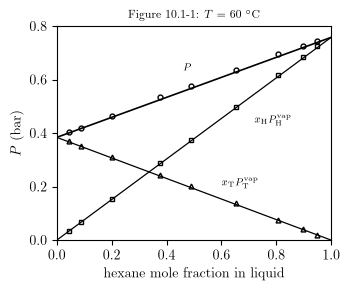

In [6]:
PH, PT = 0.7583e5, 0.3843e5                  # SIS Sec. 10.1, at 60 C
xg = np.linspace(0, 1, 101)

fig, ax = plt.subplots(figsize=(3.6, 3.0))
ax.plot(xg, (xg*PH + (1-xg)*PT)/1e5, "-",  color="k", lw=1.2)   # total
ax.plot(xg, (xg*PH)/1e5,             "-",  color="k", lw=0.9)   # hexane partial
ax.plot(xg, ((1-xg)*PT)/1e5,         "-",  color="k", lw=0.9)   # triethylamine partial
ax.plot(x_hex, P_data/1e5,           "o",  mfc="none", color="k", ms=3.5)
ax.plot(x_hex, y_hex*P_data/1e5,     "s",  mfc="none", color="k", ms=3.5)
ax.plot(x_hex, (1-y_hex)*P_data/1e5, "^",  mfc="none", color="k", ms=3.5)
ax.text(0.46, 0.635, "$P$", fontsize=7)
ax.text(0.72, 0.44, r"$x_{\rm H}P_{\rm H}^{\rm vap}$", fontsize=7)
ax.text(0.60, 0.205, r"$x_{\rm T}P_{\rm T}^{\rm vap}$", fontsize=7)
ax.set_xlabel("hexane mole fraction in liquid"); ax.set_ylabel("$P$ (bar)")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.8)
ax.set_title(r"Figure 10.1-1: $T$ = 60 $^\circ$C", fontsize=8)
fig.tight_layout()

## Figure 10.1-2 &mdash; the x-y diagram at 60 °C

The same data as a composition diagram, with the Raoult prediction through it.

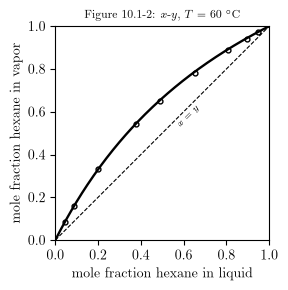

In [7]:
mix60_xy = GammaPhi([TabulatedPsat(PH), TabulatedPsat(PT)], Ideal())
xh, yh, _ = pxy(mix60_xy, T60)

fig, ax = plt.subplots(figsize=(3.2, 3.0))
xy_chart(ax, xh, yh, species="hexane", data=(x_hex, y_hex))
ax.set_title(r"Figure 10.1-2: $x$-$y$, $T$ = 60 $^\circ$C", fontsize=8)
fig.tight_layout()

## Figure 10.1-3 &mdash; the P-x-y diagram at 60 °C

The bubble and dew curves at fixed temperature, with a tie line joining a liquid to the
vapor in equilibrium with it. The chapter uses this figure to define the **bubble point
pressure** and **dew point pressure**, and it quotes both for an equimolar mixture &mdash;
which makes them a check on the whole construction.

In [8]:
mix60 = GammaPhi(book, Ideal(), names=["hexane", "triethylamine"])
z = [0.5, 0.5]
Pb, y = mix60.bubble_pressure(z, T60)
Pd, x = mix60.dew_pressure(z, T60)

print("equimolar hexane / triethylamine at 60 C")
print(f"  bubble point pressure  {Pb/1e5:.4f} bar   vapor  y_hexane = {y[0]:.4f}")
print(f"  dew    point pressure  {Pd/1e5:.4f} bar   liquid x_hexane = {x[0]:.4f}")
print("  SIS Sec. 10.1: dew at 0.5100 bar, first drop 0.3363 mole fraction hexane")

equimolar hexane / triethylamine at 60 C
  bubble point pressure  0.5713 bar   vapor  y_hexane = 0.6637
  dew    point pressure  0.5101 bar   liquid x_hexane = 0.3363
  SIS Sec. 10.1: dew at 0.5100 bar, first drop 0.3363 mole fraction hexane


That reproduces the printed dew point to four figures &mdash; 0.5101 bar against 0.5100,
and the composition exactly. *Why* that is a real check and not a
tautology: the dew-point calculation iterates on an unknown liquid composition, so
recovering both numbers at once from two vapor pressures is a statement about the solver,
not about arithmetic.

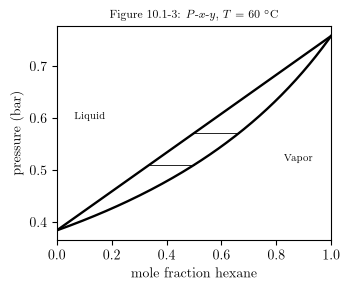

In [9]:
x1, y1, P = pxy(mix60, T60)

fig, ax = plt.subplots(figsize=(3.6, 3.0))
pxy_chart(ax, x1, y1, P, species="hexane")
tie_lines(ax, x1, y1, P, [Pd, Pb])
ax.set_title(r"Figure 10.1-3: $P$-$x$-$y$, $T$ = 60 $^\circ$C", fontsize=8)
fig.tight_layout()

## Figures 10.1-4 and 10.1-5 &mdash; constant pressure, 0.7 bar

Now the temperature is the unknown at each composition. The endpoints of the diagram are
the two pure-component boiling points at 0.7 bar, and those are checked against the
printed figure before drawing anything: **Figure 10.1-4's own ordinate runs from 58 to
77.5 °C.**

In [10]:
P07 = 0.7e5
mix07 = GammaPhi(db, Ideal(), names=["hexane", "triethylamine"])

for d in db:
    print(f"  {d.name:16s} boils at {d.T_sat(P07)-273.15:6.2f} C at 0.7 bar")
print("  Figure 10.1-4's printed ordinate spans 58 to 77.5 C")

x1b, y1b, T = txy(mix07, P07)
print(f"\n  bubble T at x_hexane = 0.5: {np.interp(0.5, x1b, T)-273.15:.2f} C")

  n-hexane         boils at  57.43 C at 0.7 bar
  triethylamine    boils at  76.93 C at 0.7 bar
  Figure 10.1-4's printed ordinate spans 58 to 77.5 C

  bubble T at x_hexane = 0.5: 65.79 C


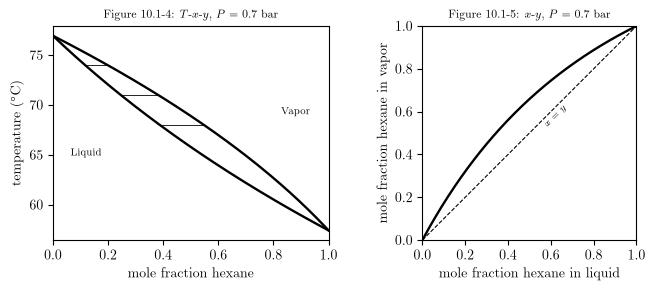

In [11]:
fig, (ax4, ax5) = plt.subplots(1, 2, figsize=(6.9, 3.0))

txy_chart(ax4, x1b, y1b, T, species="hexane", unit=CELSIUS)
tie_lines(ax4, x1b, y1b, T, [341.15, 344.15, 347.15], unit=CELSIUS)
ax4.set_title("Figure 10.1-4: $T$-$x$-$y$, $P$ = 0.7 bar", fontsize=8)

xy_chart(ax5, x1b, y1b, species="hexane")
ax5.set_title("Figure 10.1-5: $x$-$y$, $P$ = 0.7 bar", fontsize=8)

fig.tight_layout()

### What the pair shows

The $x$-$y$ curve sits close to the $x = y$ diagonal along its whole length. That is the
chapter's point about this system: hexane and triethylamine have similar vapor pressures,
so the vapor is only slightly richer in hexane than the liquid it came from, and the two
would be **hard to separate by distillation**. The gap between the equilibrium curve and
the diagonal is the driving force a column has to work with, and here there is not much of
it.

Compare Illustration 10.1-1's *n*-pentane / *n*-heptane $x$-$y$ curve, which bulges far
above the diagonal: those two differ in vapor pressure by a factor of eight at 50 °C, and
they separate easily.

## Print art

In [12]:
# --- Print art: Figures 10.1-3, 10.1-4, 10.1-5 -----------------------------
# Stage as deliverables/figures/print-bw/ch10/c10f003.pdf, c10f004.pdf, c10f005.pdf
#
# Titles come off: the caption carries them in print.
#
# Fig. 10.1-3 keeps the tie line the printed art draws, at the equimolar bubble and dew
# pressures rather than at an arbitrary height, so the line in the figure is the
# one the text's worked numbers refer to.
#
# Fig. 10.1-4 gets THREE tie lines, as the printed art does. It labels them "x"
# and "y" at the left end; the region labels carry that here instead.
import os
os.makedirs("pdf", exist_ok=True)
SIZE = (3.4, 2.9)

f, a = plt.subplots(figsize=SIZE)
pxy_chart(a, x1, y1, P, species="hexane"); tie_lines(a, x1, y1, P, [Pd, Pb])
f.tight_layout(); f.savefig("pdf/Fig_10.1-3.pdf", dpi=300, bbox_inches="tight"); plt.close(f)

f, a = plt.subplots(figsize=SIZE)
txy_chart(a, x1b, y1b, T, species="hexane", unit=CELSIUS)
tie_lines(a, x1b, y1b, T, [341.15, 344.15, 347.15], unit=CELSIUS)
f.tight_layout(); f.savefig("pdf/Fig_10.1-4.pdf", dpi=300, bbox_inches="tight"); plt.close(f)

f, a = plt.subplots(figsize=SIZE)
xy_chart(a, x1b, y1b, species="hexane")
f.tight_layout(); f.savefig("pdf/Fig_10.1-5.pdf", dpi=300, bbox_inches="tight"); plt.close(f)
f, a = plt.subplots(figsize=SIZE)
a.plot(xg, (xg*PH + (1-xg)*PT)/1e5, "-", color="k", lw=1.2)
a.plot(xg, (xg*PH)/1e5, "-", color="k", lw=0.9)
a.plot(xg, ((1-xg)*PT)/1e5, "-", color="k", lw=0.9)
a.plot(x_hex, P_data/1e5, "o", mfc="none", color="k", ms=3.5)
a.plot(x_hex, y_hex*P_data/1e5, "s", mfc="none", color="k", ms=3.5)
a.plot(x_hex, (1-y_hex)*P_data/1e5, "^", mfc="none", color="k", ms=3.5)
a.text(0.46, 0.635, "$P$", fontsize=7)
a.text(0.72, 0.44, r"$x_{\rm H}P_{\rm H}^{\rm vap}$", fontsize=7)
a.text(0.60, 0.205, r"$x_{\rm T}P_{\rm T}^{\rm vap}$", fontsize=7)
a.set_xlabel("hexane mole fraction in liquid"); a.set_ylabel("$P$ (bar)")
a.set_xlim(0, 1); a.set_ylim(0, 0.8)
f.tight_layout(); f.savefig("pdf/Fig_10.1-1.pdf", dpi=300, bbox_inches="tight"); plt.close(f)

f, a = plt.subplots(figsize=(3.2, 3.0))
xy_chart(a, xh, yh, species="hexane", data=(x_hex, y_hex))
f.tight_layout(); f.savefig("pdf/Fig_10.1-2.pdf", dpi=300, bbox_inches="tight"); plt.close(f)
print("wrote pdf/Fig_10.1-1.pdf ... pdf/Fig_10.1-5.pdf")

wrote pdf/Fig_10.1-1.pdf ... pdf/Fig_10.1-5.pdf


## Your turn

1. Figure 10.1-3 was drawn from the book's two vapor pressures and Figures 10.1-4 and
   10.1-5 from the database. Redraw 10.1-3 using `psat_from_database` at 60 °C instead.
   How far does the dew point move, and would you still call the printed 0.5100 bar right?
2. The tie line on Figure 10.1-3 was placed at the equimolar bubble and dew pressures.
   What is the *widest* tie line on this diagram, and what does its width tell you about
   where distillation of this mixture is easiest?
3. Section 10.1 says these two species "form an essentially ideal mixture." Test it: with
   `VanLaar` from `thermo.activity_models`, how large do $\alpha$ and $\beta$ have to get
   before the $x$-$y$ curve visibly departs from the ideal one drawn above?